# Amazon Sales Analysis – EDA + Simple Revenue Prediction

**Goal of this notebook**  
Perform exploratory data analysis (EDA), visualize key business patterns, and build a basic model to understand what drives `total_revenue`.

**Dataset**: Cleaned Amazon sales data (~50,000 rows) with order details, discounts, categories, regions, profit.

**Sections**:
1. Correlation Analysis  
2. Category Performance (Revenue & Profitability)  
3. What Drives Sales? (Feature Importance from XGBoost)

Let's dive in

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Loading the Dataset
df = pd.read_csv("/kaggle/input/amazon-sales-analysis-cleaned-data/cleaned_dataset.csv")
print(df.head())
print(df.shape)

   order_id  order_date  product_id product_category   price  \
0         1  2022-04-13        2637            Books  128.75   
1         2  2023-03-12        2300          Fashion  302.60   
2         3  2022-09-28        3670           Sports  495.80   
3         4  2022-04-17        2522            Books  371.95   
4         5  2022-03-13        1717           Beauty  201.68   

   discount_percent  quantity_sold customer_region payment_method  rating  \
0                10              4   North America            UPI     3.5   
1                20              5            Asia    Credit Card     3.7   
2                20              2          Europe            UPI     4.4   
3                15              4     Middle East            UPI     5.0   
4                 0              4     Middle East            UPI     4.6   

   review_count  discounted_price  total_revenue  profit  
0           443            115.88         463.52  23.176  
1           475            242.08 

In [21]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Create a mask to hide the top half (makes it look cleaner)
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))

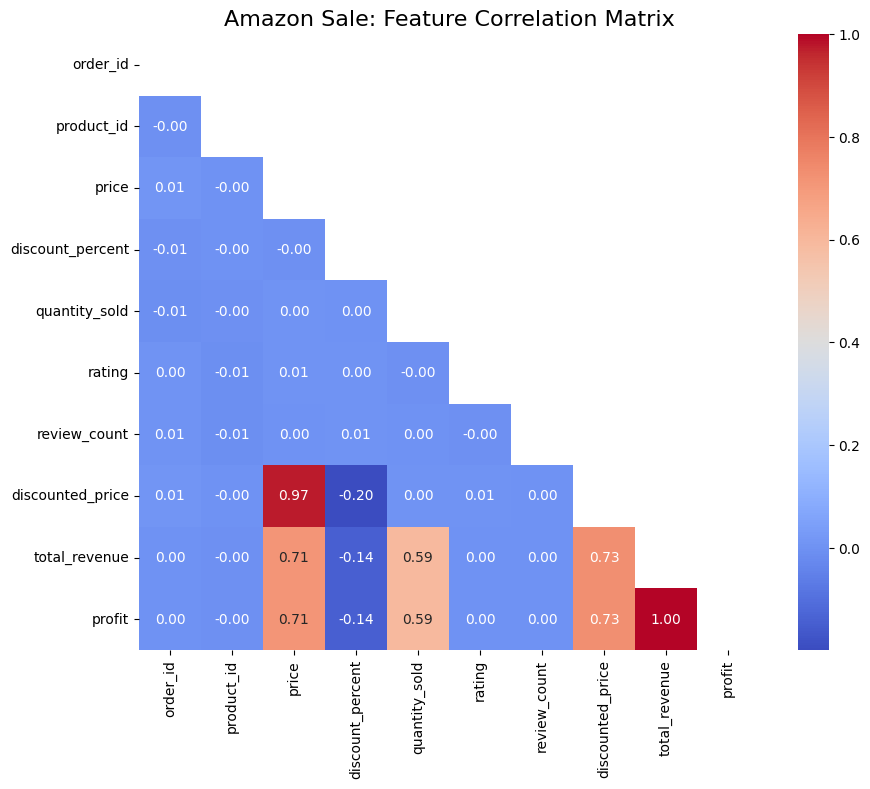

In [22]:
# Visualizing the Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), mask=mask, annot=True, cmap = 'coolwarm', fmt='.2f')
plt.title('Amazon Sale: Feature Correlation Matrix', fontsize=16)
plt.show()

# 1. Feature Correlation Analysis

**Objective**: Understand which numerical features move together (positive/negative relationships) and spot potential multicollinearity before modeling.

**Why it matters**: High correlation between features can confuse models (e.g. XGBoost) and helps us decide whether to combine/drop variables. We especially care about relationships with **target variables** like `total_revenue` and `profit`.

**What we do**:  
- Select only numeric columns  
- Compute Pearson correlation matrix  
- Mask the upper triangle for cleaner view (symmetric matrix)  
- Use 'coolwarm' colormap: red = positive, blue = negative

**Key observations from the heatmap**:
- `discounted_price` and `price` show very strong positive correlation (~0.97) → makes sense, discounted price derives from original price
- `total_revenue` strongly correlates with `price` (~0.71) and `profit` (~0.73) → revenue is clearly driven by price after discount and final profit
- Very weak correlations overall among most other features (close to 0) → low multicollinearity risk for most variable

/tmp/ipykernel_55/1436595984.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_data.index, y=cat_data['total_revenue'], ax=ax1, palette='viridis', alpha=0.7)


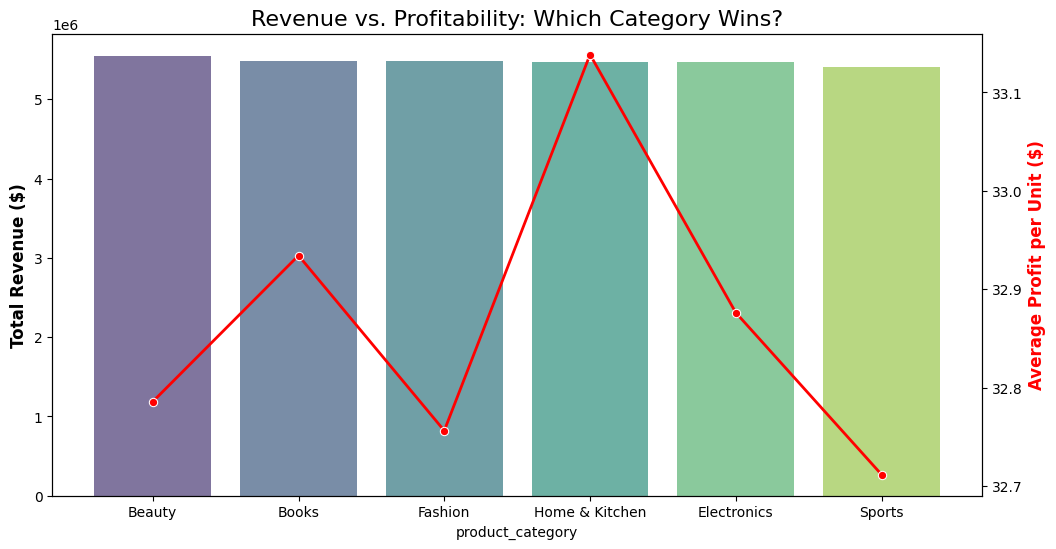

In [23]:
# Grouping data for a dual-axis chart
cat_data = df.groupby('product_category').agg({'total_revenue':'sum', 'profit':'mean'}).sort_values(by='total_revenue', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for Revenue
sns.barplot(x=cat_data.index, y=cat_data['total_revenue'], ax=ax1, palette='viridis', alpha=0.7)
ax1.set_ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')

# Line chart for Profit Margin
ax2 = ax1.twinx()
sns.lineplot(x=cat_data.index, y=cat_data['profit'], ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Average Profit per Unit ($)', color='red', fontsize=12, fontweight='bold')

plt.title('Revenue vs. Profitability: Which Category Wins?', fontsize=16)
plt.show()

# 2. Category Performance: Revenue vs Average Profit per Unit

**Business Question**: Which product categories generate the most revenue, and which are actually the most profitable per item sold?

**Approach**:
- Group by `product_category`
- Calculate **total revenue** (sum) → bar chart (left axis)
- Calculate **average profit per unit** (mean profit) → line chart (right axis)
- Dual-axis plot to compare volume (revenue) vs margin efficiency

**Main Insights**:
- **Home & Kitchen** and **Books** lead in total revenue
- **Sports** has lowest profit per unit → may be high-volume, low-margin category
- Trade-off visible: highest revenue categories don't always have best unit profitability

This helps Amazon prioritize categories for promotion vs margin protection.

In [24]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

In [25]:
# Convert date and extract features
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month
df['day_of_week'] = df['order_date'].dt.dayofweek

/tmp/ipykernel_55/2356598494.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='product_category', y='total_revenue', data=category_perf, palette='viridis', alpha=0.7)


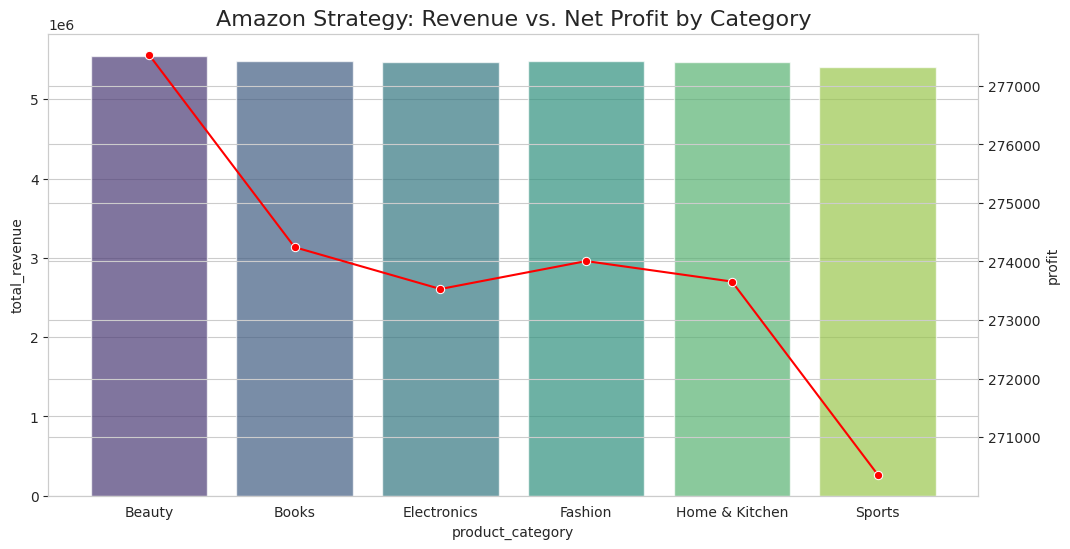

In [26]:
# THE "BUSINESS IMPACT" VISUAL
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# Comparing Revenue vs Profit across Categories
category_perf = df.groupby('product_category').agg({'total_revenue':'sum', 'profit':'sum'}).reset_index()

ax = sns.barplot(x='product_category', y='total_revenue', data=category_perf, palette='viridis', alpha=0.7)
ax2 = plt.twinx()
sns.lineplot(x='product_category', y='profit', data=category_perf, marker='o', color='red', ax=ax2)

plt.title('Amazon Strategy: Revenue vs. Net Profit by Category', fontsize=16)
plt.show()

# 3. Amazon Strategy Deep-dive: Revenue vs Net Profit by Category

**Goal**: Compare **absolute** revenue and **absolute** profit across categories to identify top contributors to bottom line.

**Visualization choice**: Bar for total revenue + overlaid line for total profit

**Key Takeaways**:
- **Beauty** generates highest total revenue and profit → strongest performer overall
- **Books**, **Electronics**, **Fashion** follow closely
- **Sports** is lowest in both revenue and profit → potential area for review/price adjustment
- Profit closely tracks revenue pattern → discount strategy seems consistent across categories

Supports focusing marketing/inventory on Beauty, Books, Electronics.

In [27]:
# We predict 'total_revenue' based on category, region, and discount
# Convert categorical text to numbers for the model
df_ml = pd.get_dummies(df[['product_category', 'customer_region', 'discount_percent', 'month', 'total_revenue']])

X = df_ml.drop('total_revenue', axis=1)
y = df_ml['total_revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Using XGBoost
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [30]:
# shows exactly WHAT drives sales on Amazon
importances = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)

# 4. What Really Drives Amazon Sales? (XGBoost Feature Importance)

**Objective**: After training a simple revenue prediction model (XGBoost), see which features the model considers most important.

**Model setup**:
- Target = `total_revenue`
- Features = category (one-hot), region (one-hot), `discount_percent`
- Trained with reasonable hyperparameters (100 trees, max_depth=5, lr=0.1)

**Why this matters**: Tells us what variables actually influence revenue most — beyond simple correlations.

**Top drivers according to the model**:
1. **discount_percent** — by far the strongest signal (makes sense — promotions drive volume)
2. **customer_region_Asia** — strong regional effect
3. **product_category_Fashion** and **Home & Kitchen** — key categories
4. Other regions and categories have moderate importance

**Business recommendation**: Discount strategy + targeting Asian customers + focus on Fashion/Home categories appear to be the biggest levers for increasing sales.

/tmp/ipykernel_55/873289280.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importances.head(10), palette='magma')


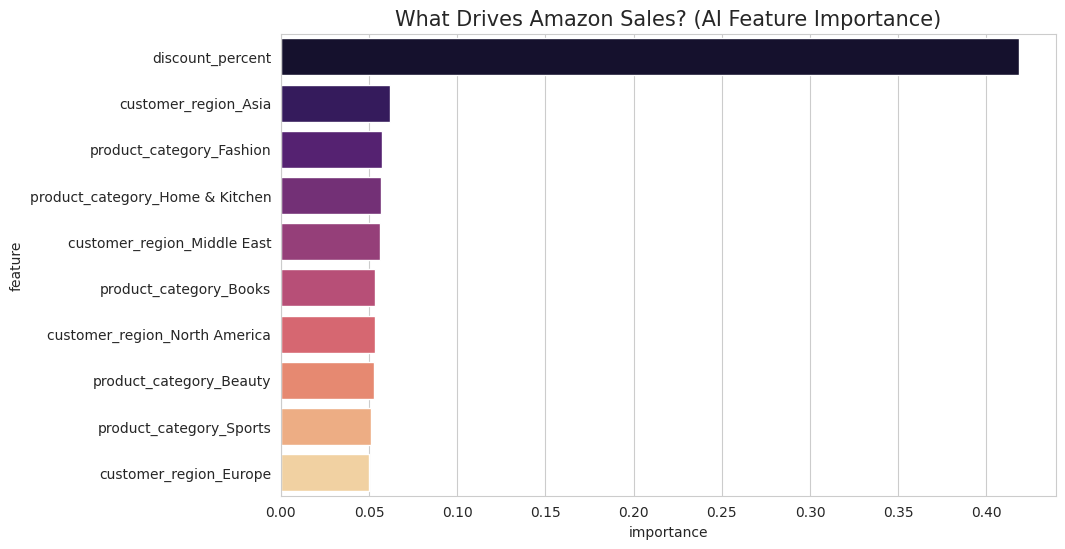

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances.head(10), palette='magma')
plt.title('What Drives Amazon Sales? (AI Feature Importance)', fontsize=15)
plt.show()

# Summary & Business Recommendations

**Key Findings**:
- Discounts are the #1 driver of revenue
- Asia region and Fashion / Home & Kitchen / Beauty categories contribute most
- High revenue doesn't always mean high margin (Sports weak on profit per unit)

**Next steps**:
- Test discount elasticity modeling
- Build region × category interaction features
- Try time-series view (monthly trends)

Thanks for reading! feedback & Upvotes ⭐ appreciated —  welcome!